In [3]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Load Data
df = pd.read_csv('data_praktikum_analisis_data - data_praktikum_analisis_data (1).csv')

# 2. Data Cleaning
# Mengisi nilai kosong pada Total_Sales dengan rumus (Quantity * Price_Per_Unit)
df['Total_Sales'] = df['Total_Sales'].fillna(df['Quantity'] * df['Price_Per_Unit'])

# Memastikan tidak ada harga negatif (anomali)
df = df[df['Price_Per_Unit'] > 0]

# Mengubah tipe data Order_Date menjadi datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

print(df.info()) # Memastikan semua data sudah bersih

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          150 non-null    int64         
 1   CustomerID        150 non-null    int64         
 2   Order_Date        150 non-null    datetime64[ns]
 3   Product_Category  150 non-null    object        
 4   Quantity          150 non-null    int64         
 5   Price_Per_Unit    150 non-null    float64       
 6   Ad_Budget         150 non-null    float64       
 7   Total_Sales       150 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(3), object(1)
memory usage: 9.5+ KB
None


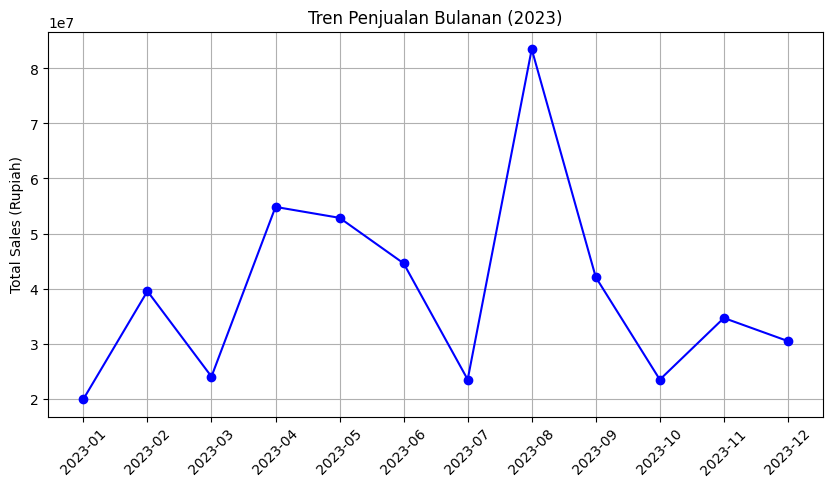

In [4]:
# Analisis Tren Penjualan Bulanan
df['Month'] = df['Order_Date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b')
plt.title('Tren Penjualan Bulanan (2023)')
plt.xticks(rotation=45)
plt.ylabel('Total Sales (Rupiah)')
plt.grid(True)
plt.show()

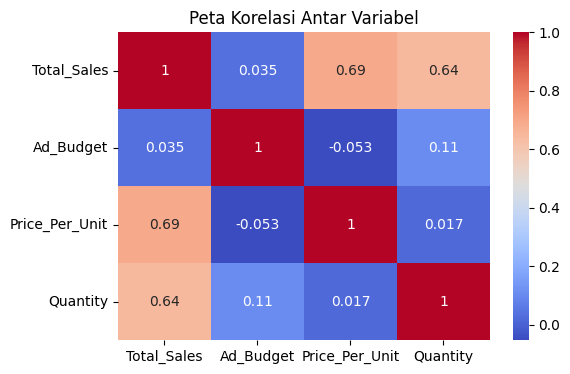

In [5]:
# Visualisasi Peta Korelasi
correlation = df[['Total_Sales', 'Ad_Budget', 'Price_Per_Unit', 'Quantity']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Peta Korelasi Antar Variabel')
plt.show()

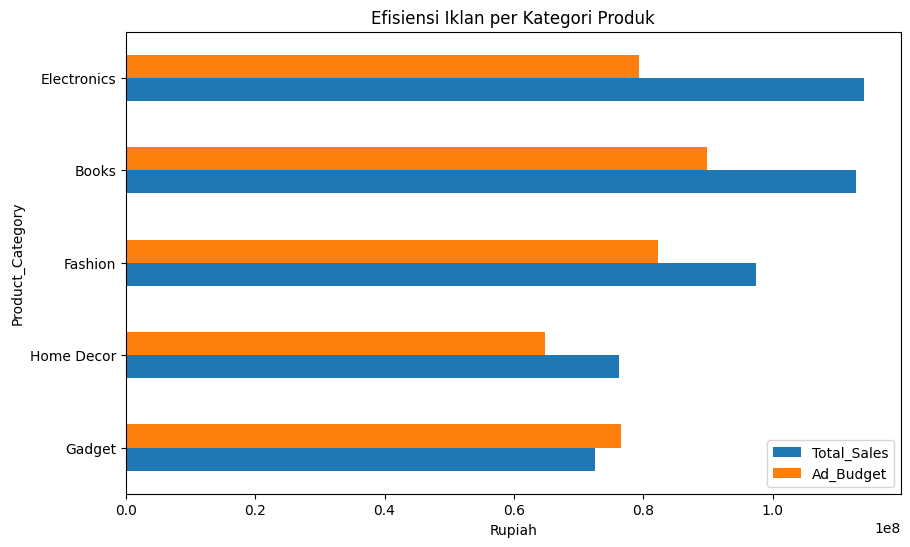

In [6]:
# Analisis Kontribusi Kategori
cat_eff = df.groupby('Product_Category').agg({'Total_Sales': 'sum', 'Ad_Budget': 'sum'})
cat_eff['ROI'] = cat_eff['Total_Sales'] / cat_eff['Ad_Budget']
cat_eff = cat_eff.sort_values(by='ROI', ascending=True)

cat_eff[['Total_Sales', 'Ad_Budget']].plot(kind='barh', figsize=(10,6))
plt.title('Efisiensi Iklan per Kategori Produk')
plt.xlabel('Rupiah')
plt.show()

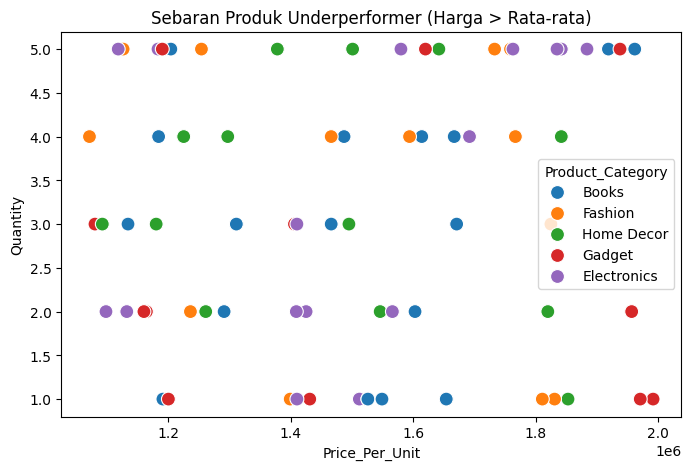

In [7]:
# Mencari Underperformer (Harga tinggi, Volume Rendah)
avg_price = df['Price_Per_Unit'].mean()
underperformers = df[df['Price_Per_Unit'] > avg_price]

plt.figure(figsize=(8,5))
sns.scatterplot(data=underperformers, x='Price_Per_Unit', y='Quantity', hue='Product_Category', s=100)
plt.title('Sebaran Produk Underperformer (Harga > Rata-rata)')
plt.show()

In [8]:
# 1. RFM Analysis
snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days,
    'Order_ID': 'count',
    'Total_Sales': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
print("Contoh Data RFM:")
print(rfm.head())

# 2. Regresi Linear Sederhana
X = df[['Ad_Budget']] 
y = df['Total_Sales'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
print(f"\nKoefisien Iklan: {model.coef_[0]:.2f}")
print(f"Akurasi Model (R2 Score): {model.score(X_test, y_test):.2f}")

Contoh Data RFM:
            Recency  Frequency    Monetary
CustomerID                                
5001            213          4   8562000.0
5002             77          4   8983000.0
5003            118          3   9433000.0
5004            196          3  20268000.0
5005             23          2   9105000.0

Koefisien Iklan: 0.09
Akurasi Model (R2 Score): -0.07
